In [16]:
import itertools
from json import load
import os
import sys

sys.path.append(os.path.abspath('../src'))

import catboost

import joblib
from matplotlib.pyplot import imshow, ylabel, xlabel, yticks, xticks,\
                                plot, margins
import numpy as np
import polars as pl
from sklearn.base import BaseEstimator
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score,\
                            confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.multiclass import OutputCodeClassifier
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

from feature_extractor import FeatureExtractor


In [2]:
SEED = 42


In [4]:
dataset = pl.read_csv(
    '../data/processed/train.csv'
    ).drop('StimSite', 'Error_type_annot')


# Приготовления

## Разбиение на фолды

In [6]:
stratified_k_fold = StratifiedKFold(n_splits=5,
                                    random_state=SEED,
                                    shuffle=True)

feature_extractor = FeatureExtractor()

big_X_raw = dataset.drop('error_type_label')
big_y_raw = dataset['error_type_label']

folds_train: list[tuple[pl.DataFrame, pl.Series]] = []
folds_val: list[tuple[pl.DataFrame, pl.Series]] = []

for train_indices, val_indices in stratified_k_fold.split(
                                        np.zeros(dataset.height),
                                        big_y_raw):
    folds_train.append((
        feature_extractor.fit_transform(big_X_raw[train_indices]),
        big_y_raw[train_indices]
    ))
    folds_val.append((
        feature_extractor.transform(big_X_raw[val_indices]),
        big_y_raw[val_indices]
    ))
    assert (folds_train[-1][0].sum_horizontal().sum() * 0) == 0
    assert (folds_train[-1][0].null_count().sum_horizontal().sum()) == 0


1462it [00:16, 89.66it/s] 
702it [00:06, 102.51it/s]
1448it [00:16, 85.76it/s]
679it [00:07, 87.45it/s] 
1450it [00:16, 86.57it/s] 
698it [00:07, 88.12it/s] 
1444it [00:16, 87.72it/s]
697it [00:07, 93.11it/s] 
1461it [00:14, 97.91it/s]
697it [00:06, 113.30it/s]


In [7]:
joblib.dump((folds_train, folds_val), 'features.joblib.xz', 9)


['features.joblib.xz']

In [3]:
folds_train, folds_val = joblib.load('features.joblib.xz')


## Функция для оценивания

In [4]:
error_type_ids_file = open('../data/processed/error_type_ids.json',
                        'r', -1, 'utf-8')
error_type_ids = load(error_type_ids_file)
error_type_ids_to_names: list[str] = [''] * 8
for k, v in error_type_ids.items():
    error_type_ids_to_names[v] = k


In [5]:
def evaluate(model: BaseEstimator,
    folds_train: list[tuple[pl.DataFrame, pl.Series]] = folds_train,
    folds_val: list[tuple[pl.DataFrame, pl.Series]] = folds_val,
    error_type_ids_to_names: list[str] = error_type_ids_to_names,
    *,
    include_classes: set[int] | None = None,
    merge_classes: list[int] | None = None,
    merge_classes_names: list[str] | None = None,
    supress_plot: bool = False,
    supress_print: bool = False,
    include_features: list[str] | None = None,
    exclude_features: list[str] | None = None):

    assert len(folds_train) == len(folds_val)
    number_of_folds: int = len(folds_train)
    classes_present: set[int] = {
                                   label 
                                   for _, y_val in folds_val 
                                   for label in y_val.unique().to_list()
                                }
    
    if include_classes:
        classes_present &= include_classes
    else:
        include_classes = classes_present

    if merge_classes:
        classes_present = {merge_classes[class_]
                           for class_ in classes_present}
        if merge_classes_names:
            error_type_ids_to_names = merge_classes_names
        else:
            error_type_ids_to_names = [f'Класс {i}'
                                for i
                                in range(len(error_type_ids_to_names))]
    else:
        merge_classes = [-1] * (max(classes_present) + 1)
        for class_ in classes_present:
            merge_classes[class_] = class_

    classes_present_names: list[str] = [error_type_ids_to_names[i]
                                        for i in classes_present]
    number_of_classes: int = len(classes_present)

    f1s = np.zeros((number_of_folds, number_of_classes))
    precisions = f1s.copy()
    recalls = f1s.copy()
    confusion_matrices = np.zeros((number_of_folds,
                                   number_of_classes, 
                                   number_of_classes))
    
    for i, (fold_train, fold_val)\
                            in enumerate(zip(folds_train, folds_val)):
        X_train, y_train = fold_train
        train_mask = y_train.is_in(include_classes)
        X_train, y_train = X_train.filter(train_mask),\
                                        y_train.filter(train_mask)
        y_train = pl.Series(merge_classes).gather(y_train)
        if include_features:
            X_train = X_train.select(
                pl.col(*include_features)
            )
        if exclude_features:
            X_train = X_train.select(
                pl.exclude(*exclude_features)
            )
        model.fit(X_train, y_train)

        X_val, y_val = fold_val
        val_mask = y_val.is_in(include_classes)
        X_val, y_val = X_val.filter(val_mask), y_val.filter(val_mask)
        y_val = pl.Series(merge_classes).gather(y_val)
        if include_features:
            X_val = X_val.select(
                pl.col(*include_features)
            )
        if exclude_features:
            X_val = X_val.select(
                pl.exclude(*exclude_features)
            )
        predictions = model.predict(X_val)

        precisions[i] = precision_score(y_val, predictions,
                                         average=None)
        recalls[i] = recall_score(y_val, predictions, average=None)
        f1s[i] = f1_score(y_val, predictions, average=None)
        confusion_matrices[i] = confusion_matrix(y_val, predictions,
                                                 normalize='true')
        
    np.set_printoptions(suppress=True)

    if not supress_print:
        print('Класс\t\t\tPrecision\tRecall\t\tF1')
        print(*('%s%.2f±%.2f\t%.2f±%.2f\t%.2f±%.2f' % (f'{name:<24}',
                precision_m.item(),
                precision_s.item(),
                recall_m.item(),
                recall_s.item(),
                f1_m.item(),
                f1_s.item())
                for name, precision_m, precision_s,
                        recall_m, recall_s, 
                        f1_m, f1_s
                in zip(classes_present_names,
                    precisions.mean(axis=0),
                    precisions.std(axis=0),
                    recalls.mean(axis=0),
                    recalls.std(axis=0),
                    f1s.mean(axis=0),
                    f1s.std(axis=0))), 
                sep='\n')
        print('%s%.2f±%.2f\t%.2f±%.2f\t%.2f±%.2f' % (f'{'По всем':<24}',
                precisions.mean(axis=1).mean(),
                precisions.std(axis=1).std(),
                recalls.mean(axis=1).mean(),
                recalls.std(axis=1).std(),
                f1s.mean(axis=1).mean(),
                f1s.mean(axis=1).std()))
    
    if not supress_plot:
        imshow(confusion_matrices.mean(axis=0))
        ylabel('Истина')
        xlabel('Предсказание')
        yticks(range(number_of_classes), classes_present_names)
        xticks(range(number_of_classes), classes_present_names, 
            rotation=45)

    return f1s.mean(axis=1).mean()


### Проверка функции для оценивания

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.99±0.00	0.96±0.00
speech arrest           0.86±0.13	0.75±0.19	0.77±0.12
аномия                  0.72±0.04	0.71±0.10	0.71±0.07
дизартрия               0.39±0.08	0.16±0.04	0.23±0.05
задержка                0.70±0.03	0.38±0.01	0.50±0.01
поиск слова             0.46±0.09	0.36±0.13	0.39±0.11
семантическая парафазия 0.33±0.08	0.29±0.11	0.31±0.09
фонетическая парафазия  0.64±0.06	0.42±0.05	0.50±0.03
По всем                 0.63±0.02	0.51±0.03	0.55±0.03


np.float64(0.5465690904045623)

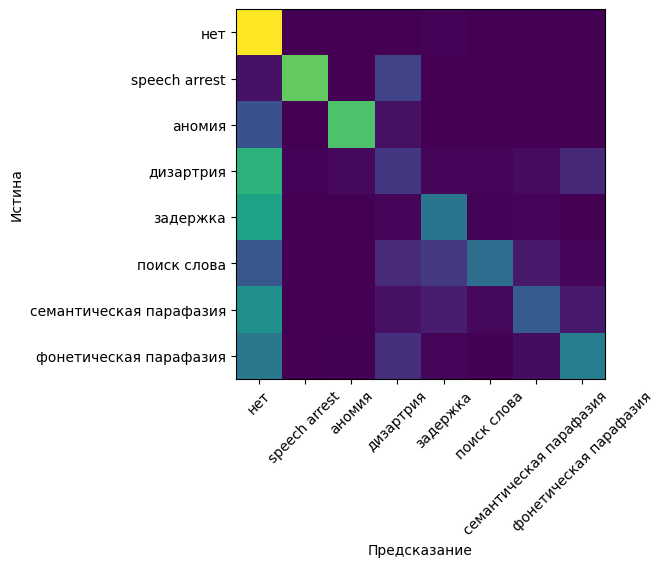

In [26]:
evaluate(DecisionTreeClassifier(max_depth=10))


Класс			Precision	Recall		F1
нет                     0.97±0.00	0.99±0.00	0.98±0.00
задержка                0.69±0.04	0.43±0.02	0.53±0.02
По всем                 0.83±0.02	0.71±0.01	0.75±0.01


np.float64(0.7549813762472961)

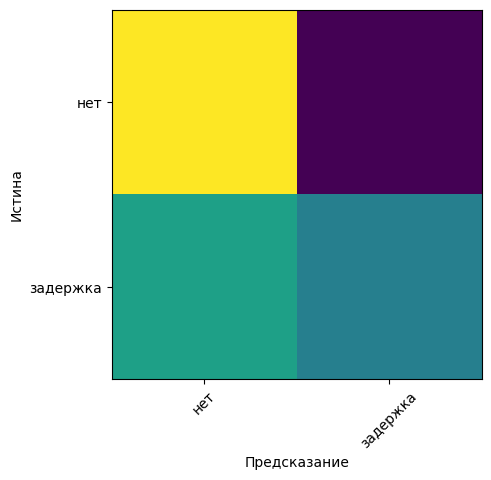

In [27]:
evaluate(DecisionTreeClassifier(max_depth=10), include_classes={0,4})


Класс			Precision	Recall		F1
нет                     0.95±0.00	0.98±0.00	0.96±0.00
есть                    0.77±0.02	0.52±0.02	0.62±0.01
По всем                 0.86±0.01	0.75±0.01	0.79±0.01


np.float64(0.7918781077982685)

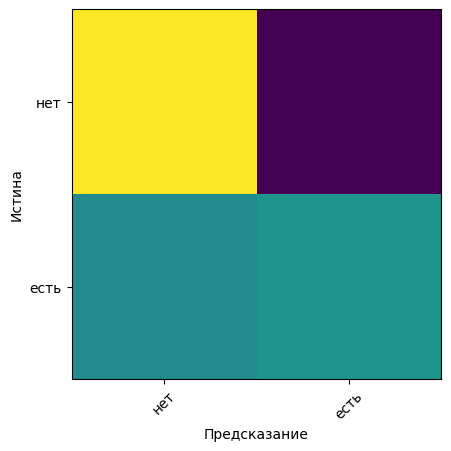

In [28]:
evaluate(DecisionTreeClassifier(max_depth=10, random_state=SEED),
         merge_classes=[0,1,1,1,1,1,1,1],
         merge_classes_names=['нет', 'есть'])


Класс			Precision	Recall		F1
Класс 0                 0.95±0.00	0.98±0.00	0.96±0.00
Класс 1                 0.77±0.02	0.52±0.02	0.62±0.01
По всем                 0.86±0.01	0.75±0.01	0.79±0.01


np.float64(0.7918781077982685)

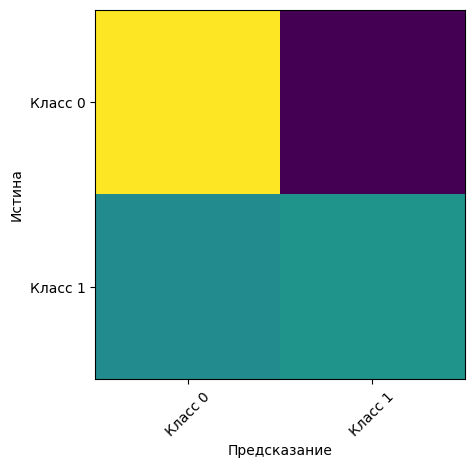

In [29]:
evaluate(DecisionTreeClassifier(max_depth=10, random_state=SEED),
         merge_classes=[0,1,1,1,1,1,1,1])


c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-

Класс			Precision	Recall		F1
нет                     0.90±0.00	1.00±0.00	0.95±0.00
speech arrest           0.00±0.00	0.00±0.00	0.00±0.00
аномия                  0.78±0.20	0.39±0.09	0.51±0.11
дизартрия               0.40±0.39	0.01±0.01	0.02±0.02
задержка                0.00±0.00	0.00±0.00	0.00±0.00
поиск слова             0.00±0.00	0.00±0.00	0.00±0.00
семантическая парафазия 0.78±0.22	0.12±0.03	0.21±0.05
фонетическая парафазия  0.70±0.18	0.09±0.04	0.15±0.06
По всем                 0.44±0.02	0.20±0.01	0.23±0.02


c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


np.float64(0.23049056942445673)

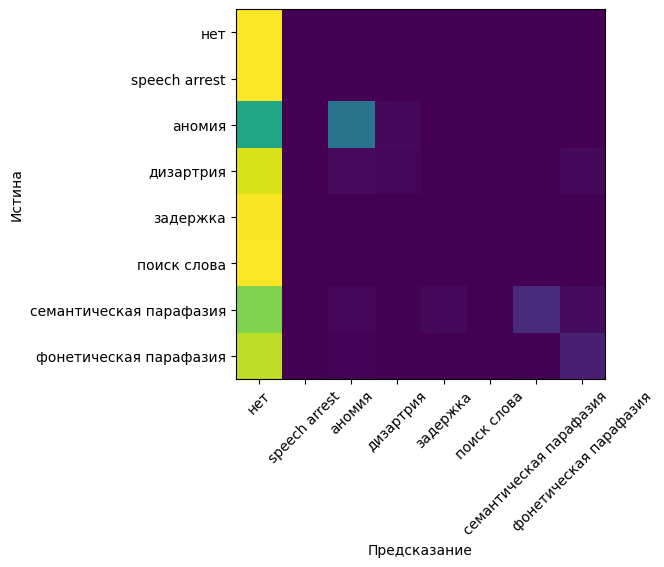

In [32]:
evaluate(DecisionTreeClassifier(max_depth=10),
         include_features=['^.+[а-яё ].+$'])

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.99±0.00	0.96±0.00
speech arrest           0.78±0.12	0.75±0.19	0.74±0.11
аномия                  0.68±0.03	0.72±0.10	0.70±0.05
дизартрия               0.39±0.06	0.15±0.03	0.22±0.04
задержка                0.69±0.03	0.39±0.02	0.50±0.02
поиск слова             0.42±0.06	0.39±0.12	0.39±0.08
семантическая парафазия 0.34±0.07	0.28±0.11	0.30±0.10
фонетическая парафазия  0.64±0.02	0.42±0.06	0.50±0.04
По всем                 0.61±0.01	0.51±0.03	0.54±0.02


np.float64(0.5397632891938822)

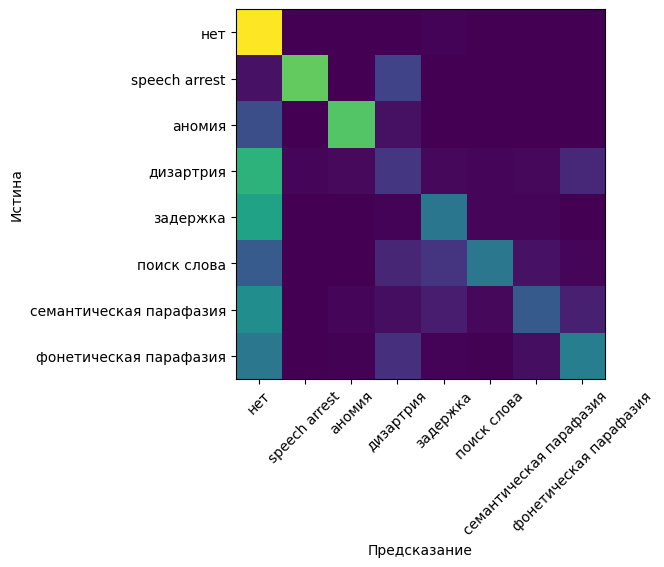

In [34]:
evaluate(DecisionTreeClassifier(max_depth=10),
         include_features=['^.+[^а-яё ].+$'])


# Бейзлайн

Просто решающее дерево с подобранной глубиной не больше 13 ($2^{13} = 8192$, в обучающих фолдах около 14 000 примеров; дерево, строго говоря, не сможет их заучить чисто созданием листов, придётся что-то обобщать).

In [14]:
best_macro_F1 = 0.0
best_max_depth = 0
for max_depth in range(1, 13+1):
    score = evaluate(DecisionTreeClassifier(max_depth=max_depth, 
                                            random_state=SEED),
                                            supress_plot=True,
                                            supress_print=True)
    if score > best_macro_F1:
        best_macro_F1 = score
        best_max_depth = max_depth


c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-Individuals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vlad\Documents\Eloquent_Areas_Classification\Automated-Classification-of-Language-Eloquent-Areas-in-Neurotypical-

In [15]:
best_max_depth


11

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.98±0.00	0.96±0.00
speech arrest           0.78±0.12	0.83±0.09	0.80±0.08
аномия                  0.72±0.05	0.71±0.10	0.71±0.06
дизартрия               0.34±0.10	0.11±0.03	0.17±0.04
задержка                0.67±0.06	0.39±0.01	0.49±0.02
поиск слова             0.43±0.15	0.41±0.21	0.42±0.18
семантическая парафазия 0.40±0.11	0.32±0.14	0.35±0.13
фонетическая парафазия  0.58±0.05	0.46±0.06	0.51±0.04
По всем                 0.61±0.03	0.53±0.03	0.55±0.03


np.float64(0.5513769171980208)

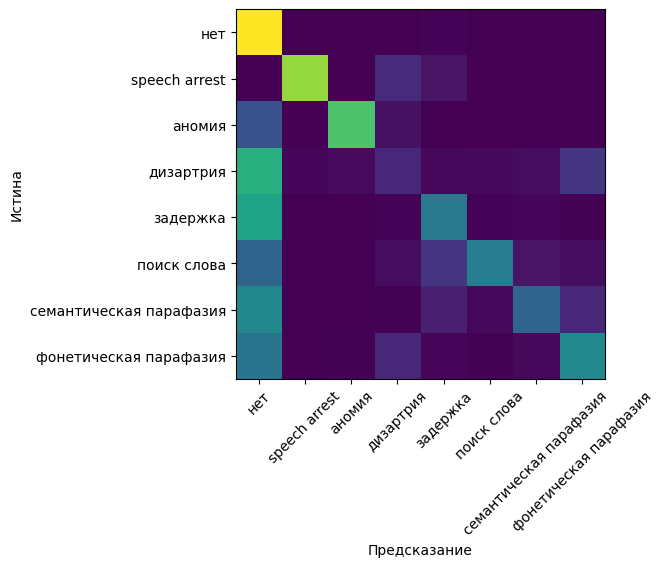

In [19]:
evaluate(DecisionTreeClassifier(max_depth=11, 
                                random_state=SEED))


# Простые подходы

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.96±0.00	0.95±0.00
speech arrest           0.88±0.10	0.80±0.18	0.83±0.12
аномия                  0.76±0.07	0.69±0.11	0.72±0.08
дизартрия               0.26±0.06	0.18±0.05	0.21±0.05
задержка                0.45±0.02	0.40±0.01	0.42±0.02
поиск слова             0.51±0.11	0.53±0.11	0.52±0.10
семантическая парафазия 0.71±0.05	0.38±0.09	0.49±0.08
фонетическая парафазия  0.53±0.07	0.47±0.07	0.49±0.06
По всем                 0.63±0.01	0.55±0.02	0.58±0.02


np.float64(0.5779264596300571)

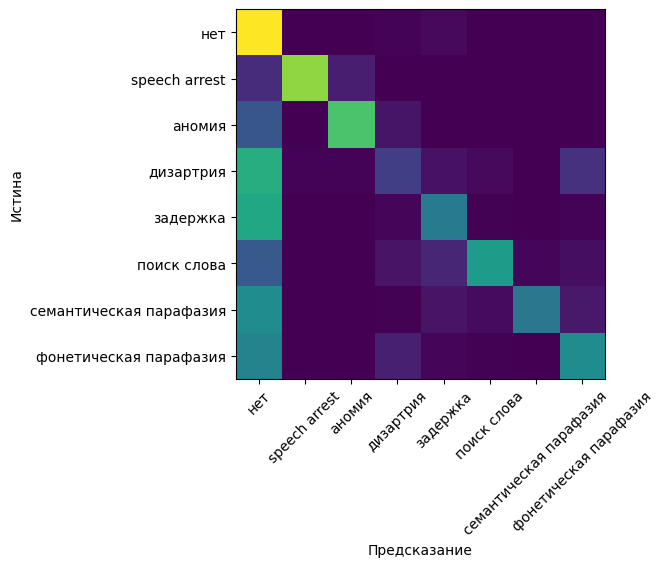

In [17]:
evaluate(RandomForestClassifier(random_state=SEED))


Лучше находит семантическую парафазию, в остальном всё так же

Класс			Precision	Recall		F1
нет                     0.94±0.00	0.99±0.00	0.97±0.00
speech arrest           0.93±0.09	0.76±0.23	0.81±0.15
аномия                  0.72±0.10	0.68±0.13	0.69±0.10
дизартрия               0.51±0.10	0.13±0.04	0.21±0.06
задержка                0.70±0.04	0.44±0.01	0.54±0.02
поиск слова             0.63±0.15	0.56±0.05	0.59±0.09
семантическая парафазия 0.68±0.05	0.37±0.10	0.48±0.10
фонетическая парафазия  0.61±0.07	0.46±0.06	0.52±0.05
По всем                 0.72±0.02	0.55±0.02	0.60±0.04


np.float64(0.6000398591699158)

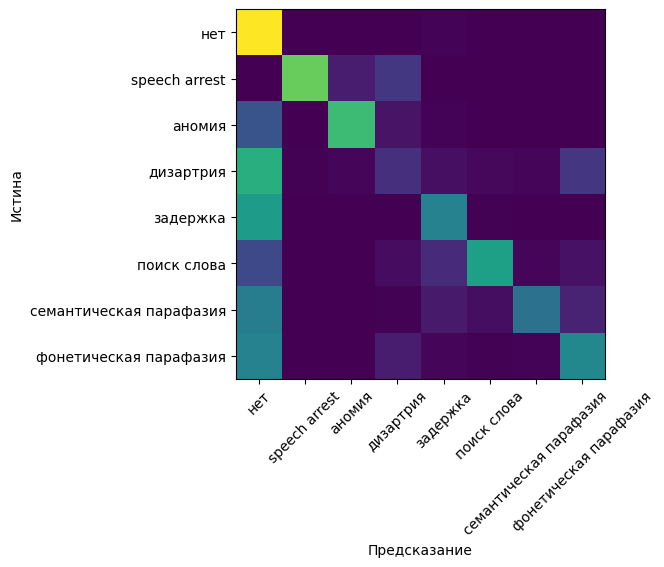

In [18]:
evaluate(catboost.CatBoostClassifier(n_estimators=1000,
                                    task_type='GPU',
                                    devices='0',
                                    random_state=SEED,
                                    silent=True))


Немного лучше RF.

# Ансамблирование

Посмотрим, какие классы (группы классов) простое decision tree лучше всего может разделить. Также посмотрим, какие признаки оно для этого использует

In [ ]:
combinations_one_v_rest = [list(i)
                for i in itertools.product([0, 1], repeat=8)][1:130]
macro_f1s_1vR: list[float] = []
trees_1vR: list[DecisionTreeClassifier] = []

for combination in combinations_one_v_rest:
    tree = DecisionTreeClassifier(max_depth=11, 
                                random_state=SEED)
    macro_f1s_1vR.append(evaluate(tree,
                              merge_classes=combination,
                              supress_plot=True,
                              supress_print=True))
    trees_1vR.append(tree)


In [ ]:
joblib.dump((macro_f1s_1vR, trees_1vR), 'class_subsets_bruteforce.joblib.xz', 9)


['class_subsets_bruteforce.joblib.xz']

In [ ]:
macro_f1s_1vR, trees_1vR = joblib.load('class_subsets_bruteforce.joblib.xz')


In [42]:
np.set_printoptions(linewidth=72, threshold=float('+inf'))

In [ ]:
np.array(macro_f1s_1vR)[np.argsort(-np.array(macro_f1s_1vR))]

array([0.93625788, 0.85062887, 0.84589687, 0.82610514, 0.81109957,
       0.8012556 , 0.79404021, 0.78948184, 0.7877796 , 0.787429  ,
       0.7868984 , 0.78680389, 0.78648162, 0.78549387, 0.78523864,
       0.78296132, 0.78242983, 0.78190612, 0.78082703, 0.77748179,
       0.77672325, 0.7758751 , 0.77490262, 0.77438203, 0.77390942,
       0.77350677, 0.77070169, 0.76921292, 0.76918227, 0.76880662,
       0.76781659, 0.76767897, 0.76679525, 0.76621074, 0.76587118,
       0.76516964, 0.76448826, 0.76349629, 0.76312057, 0.76271955,
       0.76241922, 0.76181787, 0.76092681, 0.76071191, 0.75986093,
       0.75941493, 0.75927964, 0.75927195, 0.75924654, 0.75747348,
       0.7568501 , 0.75592437, 0.75584101, 0.75576378, 0.75554388,
       0.75541797, 0.75511062, 0.75485378, 0.75471594, 0.7528799 ,
       0.75273289, 0.75187627, 0.75168825, 0.7516132 , 0.75081216,
       0.75072501, 0.74982108, 0.74897129, 0.74770387, 0.74714901,
       0.74697538, 0.74691897, 0.74618344, 0.74603939, 0.74577

In [ ]:
np.array(combinations_one_v_rest)[np.argsort(-np.array(macro_f1s_1vR))]


array([[0, 1, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [0, 1, 1, 0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 1, 0, 0],
       [0, 1, 1, 0, 0, 0, 1, 0],
       [0, 1, 1, 1, 0, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 0, 1, 0, 1],
       [1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 1, 0, 0, 1, 0, 1],
       [0, 1, 0, 1, 0, 1, 1, 1],
       [0, 1, 1, 0, 0, 1, 1, 1],
       [0, 0, 1, 0, 0, 0, 1, 0],
       [0, 0, 1, 0, 0, 1, 0, 1],
       [0, 0, 1, 0, 0, 1, 1, 1],
       [0, 1, 1, 0, 0, 0, 1, 1],
       [0, 0, 1, 1, 1, 1, 1, 1],
       [0, 0, 1, 1, 0, 1, 1, 1],
       [0, 1, 1, 0, 0, 1, 1, 0],
       [0, 0, 1, 1, 0, 1, 0, 1],
       [0, 1, 0, 1, 1, 1, 1, 1],
       [0, 1, 1, 0, 0, 0, 0, 1],
       [0, 0, 0, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 0, 1],
       [0, 1, 1, 1, 0, 0, 0, 1],
       [0, 1, 1, 1, 1, 0, 1, 1],
       [0, 1, 0, 1, 0, 1, 0, 1],
       [0, 1, 1, 0, 1, 1, 1, 0],
       [0,

Посмотрим, какие перспективы есть для 1 vs all

In [ ]:
np.array(combinations_one_v_rest)[np.array(combinations_one_v_rest)\
                                .sum(axis=1) == 1][::-1]

array([[1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 1]])

In [ ]:
np.argsort(-np.array(macro_f1s_1vR)[np.array(combinations_one_v_rest)\
                                .sum(axis=1) == 1][::-1])


array([1, 2, 0, 5, 4, 7, 6, 3])

In [ ]:
np.sort(np.array(macro_f1s_1vR)[np.array(combinations_one_v_rest)\
                                .sum(axis=1) == 1][::-1])[::-1]

array([0.93625788, 0.84589687, 0.7868984 , 0.7528799 , 0.7272812 ,
       0.71345458, 0.65829164, 0.56885555])

И для one vs one.

In [23]:
combinations_one_v_one = [set(i)
                for i in itertools.combinations([0,1,2,3,4,5,6,7], 2)]

In [57]:
macro_f1s_1v1: list[float] = []
trees_1v1: list[DecisionTreeClassifier] = []

for combination in combinations_one_v_one:
    tree = DecisionTreeClassifier(max_depth=3, # обосновать в тексте
                                random_state=SEED)
    macro_f1s_1v1.append(evaluate(tree,
                              include_classes=combination,
                              supress_plot=True,
                              supress_print=True))
    trees_1v1.append(tree)


In [58]:
np.array(macro_f1s_1v1)[np.argsort(-np.array(macro_f1s_1v1))]

array([1.        , 1.        , 1.        , 1.        , 0.97604534,
       0.95519446, 0.95299037, 0.93137176, 0.9304713 , 0.92355684,
       0.91595902, 0.90379938, 0.89333695, 0.87410126, 0.86895984,
       0.86531207, 0.84531086, 0.83570615, 0.83371089, 0.83294184,
       0.8311701 , 0.81523525, 0.76978738, 0.63198842, 0.61699126,
       0.61354015, 0.60760504, 0.54891868])

In [59]:
np.array(combinations_one_v_one)[np.argsort(-np.array(macro_f1s_1v1))]


array([{1, 2}, {1, 7}, {1, 5}, {1, 6}, {1, 4}, {2, 7}, {2, 4}, {2, 5},
       {0, 1}, {2, 6}, {0, 2}, {2, 3}, {1, 3}, {5, 7}, {4, 7}, {6, 7},
       {3, 6}, {5, 6}, {3, 4}, {3, 5}, {4, 5}, {0, 5}, {4, 6}, {0, 7},
       {0, 4}, {3, 7}, {0, 6}, {0, 3}], dtype=object)